<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span></li><li><span><a href="#Загрузка-данных" data-toc-modified-id="Загрузка-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Загрузка данных</a></span></li><li><span><a href="#Предобработка-данных" data-toc-modified-id="Предобработка-данных-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Предобработка данных</a></span></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Обучение</a></span></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Выводы</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

# Оценка тональности отзывов

Интернет-магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 

**Цель**: обучить модель классифицировать комментарии на позитивные и негативные на наборе данных с разметкой о токсичности правок.

**Описание данных**
Данные находятся в файле `toxic_comments.csv`. Столбец *text* в нём содержит текст комментария, а *toxic* — целевой признак.

## Подготовка

In [1]:
!pip install textblob -q
!python -m textblob.download_corpora -q
! pip install tqdm -q

[nltk_data] Downloading package brown to /home/jovyan/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/jovyan/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to /home/jovyan/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
Finished.


In [2]:
import os
import re

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from textblob import TextBlob, Word

import nltk
from nltk import pos_tag, word_tokenize
from nltk.corpus import stopwords, wordnet

from tqdm import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,precision_score,recall_score
from sklearn.model_selection import GridSearchCV,cross_validate,train_test_split

from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
tqdm.pandas()

In [3]:
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
RANDOM_STATE = 42

## Загрузка данных


In [5]:
file_path = 'C:/Users/79533/Desktop/yandex_practicum/python/datasets/vikishop/toxic_comments.csv'
print("Путь существует:", os.path.exists(file_path))

Путь существует: False


In [6]:
try:
    comments = pd.read_csv('C:/Users/79533/Desktop/yandex_practicum/python/datasets/vikishop/toxic_comments.csv')

except:
    comments = pd.read_csv('https://code.s3.yandex.net/datasets/toxic_comments.csv')

In [7]:
comments.tail(5)

,Unnamed: 0,text,toxic
159287,159446,""":::::And for the second time of asking, when ...",0
159288,159447,You should be ashamed of yourself \n\nThat is ...,0
159289,159448,"Spitzer \n\nUmm, theres no actual article for ...",0
159290,159449,And it looks like it was actually you who put ...,0
159291,159450,"""\nAnd ... I really don't think you understand...",0


Мы видим, что колонка 'Unnamed: 0' отличается от нумерации, но может быть id твита. Посмотрим подробнее

In [8]:
comments[comments['Unnamed: 0'].duplicated()]

,Unnamed: 0,text,toxic


Повторов нет, используем этот столбец в качестве id

In [9]:
comments = comments.set_index('Unnamed: 0')
comments.index.name = None

In [10]:
comments.shape

(159292, 2)

## Предобработка данных

In [11]:
comments.head(2)

,text,toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0


In [12]:
comments[comments.duplicated()]

,text,toxic


дубликатов нет

In [13]:
comments.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 159292 entries, 0 to 159450
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.6+ MB


пропусков нет. 1 столбец - текст, 2й - таргет ( 0 и 1)

In [14]:
comments.describe().T

,count,mean,std,min,25%,50%,75%,max
toxic,159292.0,0.101612,0.302139,0.0,0.0,0.0,0.0,1.0


In [15]:
comments['toxic'].value_counts()


0    143106
1     16186
Name: toxic, dtype: int64

У нас явный дисбаланс классов, посмотрим нагляднее

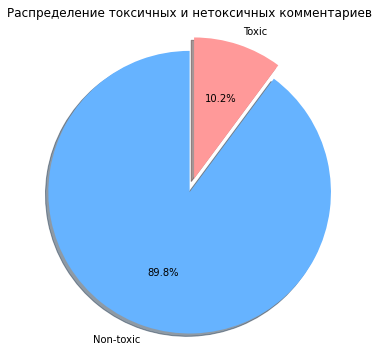

In [16]:
counts = comments['toxic'].value_counts()
labels = ['Non-toxic', 'Toxic']
sizes = [counts[0], counts[1]]  
colors = ['#66b3ff', '#ff9999']
explode = (0, 0.1) 

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, explode=explode, shadow=True)
plt.title('Распределение токсичных и нетоксичных комментариев')
plt.axis('equal')
plt.show()

Сначала почистим текст регулярными выражениями, потом лемматизируем. Будем действовать в этом порядке, потому что чистый текст лемматизируется лучше.

In [17]:
def clean_text(text):
    text = re.sub(r'@\w+', '', text)        # упоминания
    text = re.sub(r'#\w+', '', text)        # хештеги
    text = re.sub(r'http\S+', '', text)     # ссылки
    text = text.lower()
    return text

comments['text'] = comments['text'].apply(clean_text)

**лемматизация**:

In [18]:
short_text = comments.head(200).copy()

In [19]:
stop_words = set(stopwords.words('english'))

In [20]:
# вспомогательная функция. Преобразование POS-тегов из nltk в формат WordNet
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def clean_and_lemmatize(text):
    text = re.sub(r"[^\w\s]", "", text)
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)
    lemmas = [ Word(word).lemmatize(pos=get_wordnet_pos(tag)) for word, tag in pos_tags if word.lower() not in stop_words]
    return " ".join(lemmas)

In [21]:
short_text['lemmatized'] = short_text['text'].apply(clean_and_lemmatize)

Проверили на коротком тексте, что лемматизация сработала

In [22]:
short_text.head(5)

,text,toxic,lemmatized
0,explanation\nwhy the edits made under my usern...,0,explanation edits make username hardcore metal...
1,d'aww! he matches this background colour i'm s...,0,daww match background colour im seemingly stic...
2,"hey man, i'm really not trying to edit war. it...",0,hey man im really try edit war guy constantly ...
3,"""\nmore\ni can't make any real suggestions on ...",0,cant make real suggestion improvement wonder s...
4,"you, sir, are my hero. any chance you remember...",0,sir hero chance remember page thats


In [23]:
comments['lemmatized'] = comments['text'].progress_apply(clean_and_lemmatize)

100%|██████████| 159292/159292 [07:51<00:00, 337.82it/s]


In [24]:
comments.head(5)

,text,toxic,lemmatized
0,explanation\nwhy the edits made under my usern...,0,explanation edits make username hardcore metal...
1,d'aww! he matches this background colour i'm s...,0,daww match background colour im seemingly stic...
2,"hey man, i'm really not trying to edit war. it...",0,hey man im really try edit war guy constantly ...
3,"""\nmore\ni can't make any real suggestions on ...",0,cant make real suggestion improvement wonder s...
4,"you, sir, are my hero. any chance you remember...",0,sir hero chance remember page thats


Уберем ненужный столбец

In [25]:
comments.drop(columns='text', inplace=True)

Разбиваем датасет на выборки:

In [26]:
X_train, X_test, y_train, y_test = train_test_split(comments['lemmatized'],
                                                    comments['toxic'],test_size=0.3,
                                                    random_state=RANDOM_STATE,stratify=comments['toxic'])

In [27]:
y_train

34421     0
23694     0
30822     0
34003     0
137374    0
         ..
145664    0
31363     0
85871     0
54772     0
67949     0
Name: toxic, Length: 111504, dtype: int64

У нас задача классификации текстов на негативный и положительный отзывы, мы работаем с короткими текстами (отзывы). Для такой задачи подходят BoW + N-граммы

Для построения взвешенного мешка слов используем TfidfVectorizer, который оценивает важность слов в зависимости от их частоты и редкости.

## Обучение

In [28]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
    ('logreg', LogisticRegression(class_weight='balanced',
                                  solver='saga',
                                  max_iter=1000,
                                  random_state=RANDOM_STATE))
])

params = {'logreg__C': [5, 5.5, 6]}

grid = GridSearchCV(pipeline,
                    param_grid=params,
                    scoring='f1',
                    cv=3,
                    n_jobs=-1,
                    verbose=1)

grid.fit(X_train, y_train)

print("Лучший f1:", grid.best_score_)
print("Лучший параметр C:", grid.best_params_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:328: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:328: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:328: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:328: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:328: ConvergenceWarning: The max_iter was reached which means the coef_ did not 

Лучший f1: 0.7738670481854418
Лучший параметр C: {'logreg__C': 6}


/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:328: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "



<div class="alert alert-info">
<h4> Спасибо  за этот комментарий, я действительно не подумала об утечке. Меня только смутило почему он зеленый :) ведь утечка действительно была <a class="tocSkip">

In [29]:
pipeline_lgb = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 3),
        min_df=3, max_df=0.9,
        max_features=50000, sublinear_tf=True)),
    
    ('lgb', LGBMClassifier(class_weight='balanced', random_state=RANDOM_STATE))])

scoring = {'accuracy': 'accuracy',
           'precision': 'precision',
           'recall': 'recall',
           'f1': 'f1'}

cv_results = cross_validate(pipeline_lgb, X_train, y_train,
                            scoring=scoring, cv=3, n_jobs=-1)

print("Средняя accuracy:", cv_results['test_accuracy'].mean())
print("Средняя precision:", cv_results['test_precision'].mean())
print("Средняя recall:", cv_results['test_recall'].mean())
print("Средний F1:", cv_results['test_f1'].mean())

Средняя accuracy: 0.938997704118238
Средняя precision: 0.6657820698702016
Средняя recall: 0.8024718028312908
Средний F1: 0.7277639402370761


В качестве финальной модели выберем логистическую регрессию, т.к. она пказала лучший результат,который удовлетворяет нашим условиям

In [30]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

In [31]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9538796350548254
Precision: 0.757976653696498
Recall: 0.8023064250411862
F1 Score: 0.7795118047218889


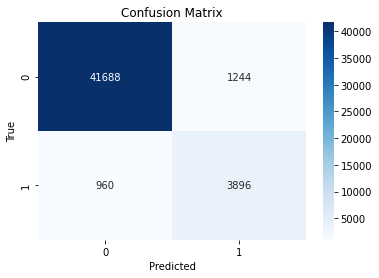

In [32]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Мы видим, что наша матрица не идеальна: у нас довольно много ложноположительных классов и чуть меньше ложноотрицательных. Наша модель смещена в сторону присваивания положительных классов в сомнительных случаях и меньше упускает действительно негативные отзывы. Но т.к. нам важнее поймать негативный отзыв для последующей работы с ним и ничего критичного не случится (хоть это и нехорошо) если положительный отзыв будет распознан как негативный то нас такой результат устраивает. Хотя конечно есть что улучшить

## Выводы

В этой работе мы разрабатывали **модель для определения негативных отзывов**. Нашим критерием был скоринг f1 не менее 75.
У нас задача бинарной классификации с дисбалансом классов. Наша цель найти как можно больше редкого класса 1(выявить негативные отзывы),пусть даже с некоторыми ложными срабатываниями. Поэтому нам важна не только метрика f1 но и recall в частности. 

В ходе работы были сделаны следующие шаги:
- выполнена установка необходимых библиотек и констант
- загружены данные
- выполнена предобработка данных: 

1) столбец "Unnamed: 0" установлен в качестве индекса

2) проведена проверка данных на дубликаты, пропуски, выявлен дисбаланс классов в таргете (89.8% 0 класса и 10.2% негативных отзывов)

3) очистили текст от никнеймов, ссылок и хештегов с помощью регулярных выражений

4) лемматизировали текст с помощью nltk

5) разбили датасет на выборки, стратифицируя по таргету

6) далее перевели лемматизированный текст в векторы с помощью TfidfVectorizer

7) готовые признаки подали в модель линейной регрессии, в которой подобрали параметр С. Также просчитали модель lgb бустинга и  но результат базовой модели оказался значительно хуже, поэтому мы не стали делать перебор гиперпараметров

В результате работы была создана модель с удовлеторительным качеством. Однако, можно попробовать улучшить ее качество, используя BERT вместо подхода лемматизация + TfidfVectorizer

Большое спасибо за ревью! Оно помогло лучше изучить работу линейной регрессии пока перебирала варианты (узнала что l1 или elasticnet считается в разы дольше обычной l2. ну и что max_features 50000 это немного ту мач). Хотя чувство что все равно в теме обработки текстов плаваю, буду добивать какими-нибудь еще источниками